# Network Data & Its Role in `vacc_sweep.py`

This notebook explains the structure of `Data/group_statistics.txt`, how each field encodes the network's group-level topology, and exactly how those numbers flow into the wAMEs (weighted Approximate Master Equations) model run by the VACC parameter sweep.

## 1 — What is `group_statistics.txt`?

`Data/group_statistics.txt` is a JSON file containing pre-computed group statistics for multiple empirical and synthetic contact networks. Each top-level key is a network name.

```
{
  "CNS":           { ... },
  "Thiers13":      { ... },
  "Synthetic_delta_k5": { ... },
  ...
}
```

The sweep uses **`Synthetic_delta_k5`** by default (see `NETWORK` constant in `vacc_sweep.py`). Empirical networks like `Thiers13` (a French high school) or `CNS` (Copenhagen Network Study) can be substituted to test model generality.

### Fields per network

| Field | Type | Used by model? | Meaning |
|---|---|---|---|
| `times` | list of int | **No** | Timestamps of each recorded snapshot (empty for synthetics) |
| `sizes` | list of int | **No** | Total number of active groups at each snapshot (empty for synthetics) |
| `group_size_n` | list of int | Yes | Distinct group sizes observed, $n \geq 2$ |
| `group_size_p` | list of float | Yes | $P(n)$ — probability a randomly-chosen group has size $n$; sums to 1 |
| `membership_k` | list of int | Yes | Distinct membership counts $k$ (number of groups an individual belongs to) |
| `membership_g` | list of float | Yes | $g(k)$ — fraction of individuals with membership count $k$; sums to 1 |

`times` and `sizes` are raw temporal metadata preserved from the original empirical datasets. `load_group_statistics()` in `vacc_sweep.py` only reads `group_size_n/p` and `membership_k/g`; the temporal fields are never loaded.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('Data/group_statistics.txt') as f:
    data = json.load(f)

print('Available networks:')
for net in data:
    d = data[net]
    print(f'  {net:30s}  n_max={max(d["group_size_n"]):3d}  k_max={max(d["membership_k"]):3d}')

Available networks:
  CNS                             n_max= 20  k_max=233
  Thiers13                        n_max=  6  k_max=  5
  LyonSchool                      n_max=  6  k_max=  5
  SFHH                            n_max= 11  k_max=  4
  InVS15                          n_max=  7  k_max=  6
  Malawi                          n_max=  5  k_max=  3
  LH10                            n_max=  7  k_max=  4
  InVS13                          n_max=  4  k_max=  4
  Synthetic_delta_k1              n_max=  6  k_max=  1
  Synthetic_delta_k2              n_max=  6  k_max=  2
  Synthetic_delta_k3              n_max=  6  k_max=  3
  Synthetic_delta_k5              n_max=  6  k_max=  5
  Synthetic_poisson_k2            n_max=  6  k_max= 15
  Synthetic_poisson_k3            n_max=  6  k_max= 19
  Synthetic_poisson_k5            n_max=  6  k_max= 25


## 2 — Group-size distribution $P(n)$

$P(n)$ is the probability that a randomly-sampled group has exactly $n$ members. It characterises how interactions are bundled — dyadic ($n=2$) vs. larger hyperedges.

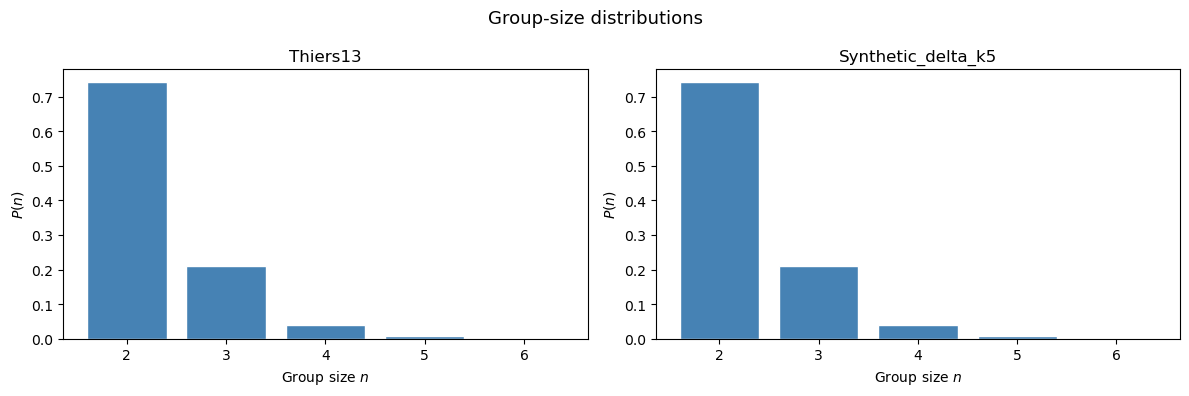

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, net in zip(axes, ['Thiers13', 'Synthetic_delta_k5']):
    d = data[net]
    ns = d['group_size_n']
    ps = d['group_size_p']
    ax.bar(ns, ps, color='steelblue', edgecolor='white')
    ax.set_title(net)
    ax.set_xlabel('Group size $n$')
    ax.set_ylabel('$P(n)$')
    ax.set_xticks(ns)

plt.suptitle('Group-size distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 3 — Membership distribution $g(k)$

$g(k)$ is the fraction of individuals who simultaneously belong to exactly $k$ groups. It governs how many "social contexts" each person is exposed to — and therefore how quickly a spreading process can reach them through different channels.

The **synthetic** networks are designed to isolate the effect of $k$:

- `Synthetic_delta_k5` — all individuals have **exactly** $k = 5$ memberships (delta distribution)
- `Synthetic_poisson_k5` — memberships are **Poisson-distributed** with mean $\langle k \rangle = 5$

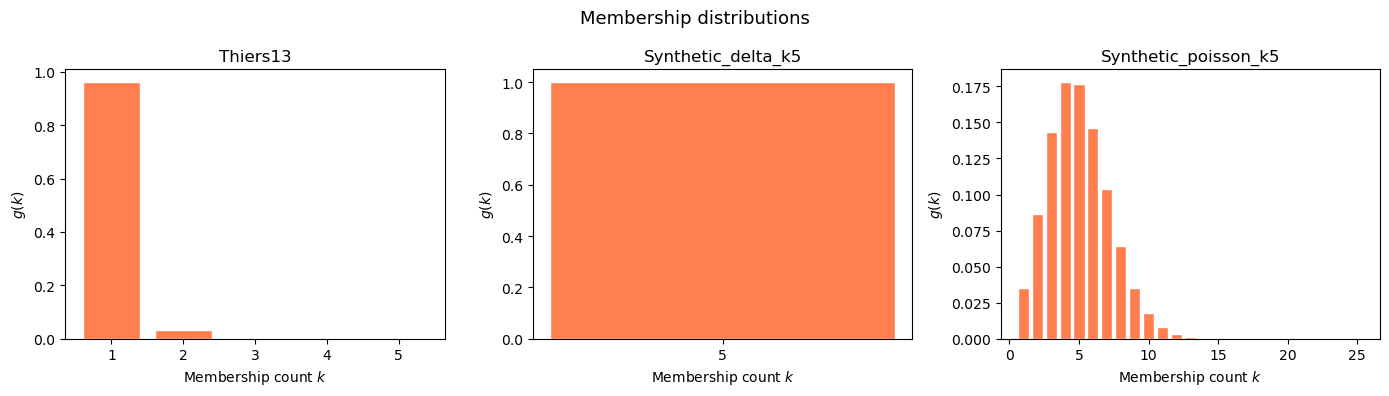

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, net in zip(axes, ['Thiers13', 'Synthetic_delta_k5', 'Synthetic_poisson_k5']):
    d = data[net]
    ks = d['membership_k']
    gs = d['membership_g']
    ax.bar(ks, gs, color='coral', edgecolor='white')
    ax.set_title(net)
    ax.set_xlabel('Membership count $k$')
    ax.set_ylabel('$g(k)$')
    if len(ks) <= 15:
        ax.set_xticks(ks)

plt.suptitle('Membership distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 4 — How the data flows into `vacc_sweep.py`

### 4.1 Loading and reshaping

`load_group_statistics()` converts the sparse lists into dense 1-D numpy arrays indexed from 0:

```python
pn = np.zeros(nmax + 1)   # pn[n] = P(n)
gm = np.zeros(mmax + 1)   # gm[k] = g(k)
```

Indices 0 and 1 are unused (no groups of size < 2; no individual in 0 groups). The code then calls `_get_state_meta()` to pre-compute several broadcast-ready matrices that avoid recomputing inside the ODE right-hand side.

In [4]:
import sys
sys.path.insert(0, '.')
from vacc_sweep import load_group_statistics

gm, pn, mmax, nmax, state_meta = load_group_statistics('Synthetic_delta_k5')

print(f'nmax = {nmax}  (largest group size in the distribution)')
print(f'mmax = {mmax}  (largest membership count in the distribution)')
print()
print('pn (group-size distribution, dense array):')
for n in range(2, nmax + 1):
    print(f'  pn[{n}] = {pn[n]:.6f}')
print()
print('gm (membership distribution, dense array):')
for k in range(1, mmax + 1):
    print(f'  gm[{k}] = {gm[k]:.6f}')

nmax = 6  (largest group size in the distribution)
mmax = 5  (largest membership count in the distribution)

pn (group-size distribution, dense array):
  pn[2] = 0.741932
  pn[3] = 0.211722
  pn[4] = 0.038775
  pn[5] = 0.007412
  pn[6] = 0.000159

gm (membership distribution, dense array):
  gm[1] = 0.000000
  gm[2] = 0.000000
  gm[3] = 0.000000
  gm[4] = 0.000000
  gm[5] = 1.000000


### 4.2 State variables

The wAMEs model tracks two coupled objects:

| Variable | Shape | Meaning |
|---|---|---|
| `sm[k]` | `(mmax+1,)` | Fraction of susceptible individuals with membership $k$ |
| `fni[n, i]` | `(nmax+1, nmax+1)` | Fraction of groups of size $n$ that currently have exactly $i$ infected members |

These are concatenated into a single flat vector `v` for `solve_ivp`.

At $t = 0$ the system is initialised with a seed prevalence `I0`:
- `sm[k] = 1 - I0` for all $k$ — a fraction `I0` of every membership class is infected
- `fni[n, i] = Binomial(i; n, I0)` — group infection counts are drawn from a binomial, assuming random seeding

In [5]:
from scipy.stats import binom

I0 = 0.001   # low-seed initial condition
sm_init = np.full(mmax + 1, 1.0 - I0)
fni_init = np.zeros((nmax + 1, nmax + 1))
for n in range(2, nmax + 1):
    fni_init[n, :n + 1] = binom.pmf(np.arange(n + 1), n, I0)

print('sm_init (same for all k, since random seeding):', sm_init[1:mmax+1])
print()
print('fni_init for n=6 (most-infected state is essentially zero at I0=0.001):')
print(np.round(fni_init[6, :7], 8))

sm_init (same for all k, since random seeding): [0.999 0.999 0.999 0.999 0.999]

fni_init for n=6 (most-infected state is essentially zero at I0=0.001):
[9.9401498e-01 5.9700600e-03 1.4940000e-05 2.0000000e-08 0.0000000e+00
 0.0000000e+00 0.0000000e+00]


### 4.3 Pre-computed matrices from `_get_state_meta`

Several matrices are built once and reused thousands of times inside the ODE solver:

```
m     — shape (mmax+1,)            : integer index array [0, 1, 2, ..., mmax]
imat  — shape (nmax+1, nmax+1)     : imat[n, i] = i  (number of infected in group)
nmat  — shape (nmax+1, nmax+1)     : nmat[n, i] = n  (group size, broadcast)
pnmat — shape (nmax+1, nmax+1)     : pnmat[n, i] = pn[n]  (group-size prob, broadcast)
```

These allow the infection-pressure sums in `_vector_field` to be written as vectorised numpy expressions instead of Python loops.

In [6]:
mmax_sm, nmax_sm, m, gm_sm, pn_sm, imat, nmat, pnmat = state_meta

print('imat[2:, :7] (infected-count index per group-size row):')
print(imat[2:, :7])
print()
print('nmat[2:, :7] (group-size index broadcast):')
print(nmat[2:, :7])
print()
print('pnmat[2:, :7] (P(n) broadcast, non-zero only on valid (n,i) cells):')
print(np.round(pnmat[2:, :7], 4))

imat[2:, :7] (infected-count index per group-size row):
[[0. 1. 2. 0. 0. 0. 0.]
 [0. 1. 2. 3. 0. 0. 0.]
 [0. 1. 2. 3. 4. 0. 0.]
 [0. 1. 2. 3. 4. 5. 0.]
 [0. 1. 2. 3. 4. 5. 6.]]

nmat[2:, :7] (group-size index broadcast):
[[2. 2. 2. 0. 0. 0. 0.]
 [3. 3. 3. 3. 0. 0. 0.]
 [4. 4. 4. 4. 4. 0. 0.]
 [5. 5. 5. 5. 5. 5. 0.]
 [6. 6. 6. 6. 6. 6. 6.]]

pnmat[2:, :7] (P(n) broadcast, non-zero only on valid (n,i) cells):
[[7.419e-01 7.419e-01 7.419e-01 7.419e-01 7.419e-01 7.419e-01 7.419e-01]
 [2.117e-01 2.117e-01 2.117e-01 2.117e-01 2.117e-01 2.117e-01 2.117e-01]
 [3.880e-02 3.880e-02 3.880e-02 3.880e-02 3.880e-02 3.880e-02 3.880e-02]
 [7.400e-03 7.400e-03 7.400e-03 7.400e-03 7.400e-03 7.400e-03 7.400e-03]
 [2.000e-04 2.000e-04 2.000e-04 2.000e-04 2.000e-04 2.000e-04 2.000e-04]]


### 4.4 Infection pressure $r$ and $\rho$

Two aggregate pressures are computed at every ODE timestep from these matrices:

$$r = \frac{\sum_{n,i} \lambda \cdot i^\nu \cdot (n - i) \cdot f_{n,i} \cdot P(n)}{\sum_{n,i} (n - i) \cdot f_{n,i} \cdot P(n)}$$

$r$ is the per-susceptible infection rate from **within-group** contacts, weighted by $f_{n,i}$.

$$\rho = r \cdot \frac{\sum_k k(k-1) s_k g(k)}{\sum_k k \cdot s_k g(k)}$$

$\rho$ is the **excess membership** pressure — the extra infection hazard a susceptible person faces via shared group membership (analogous to the excess-degree term in network SIS models).

The membership distribution $g(k)$ enters directly here: networks with heavy-tailed $g(k)$ (like `CNS` with $k_{\max} = 233$) amplify $\rho$ substantially.

### 4.5 The switching kernel $\omega(n, i)$ and $S_w$

The diversity-tension kernel used in the sweep is:

$$\omega(n, i; \alpha) = \alpha \cdot \frac{i}{n} \cdot \left(1 - \frac{i}{n}\right)$$

This is the group-level "tension" — it peaks when half the group is infected and is zero for fully susceptible or fully infected groups. It sets the rate at which individuals leave (or join) groups.

An effective susceptible fraction among switchers is:

$$S_w = \frac{\sum_{n,i} (n - i) \cdot \omega_{n,i} \cdot f_{n,i}}{\sum_{n,i} n \cdot \omega_{n,i} \cdot f_{n,i}}$$

$S_w$ tracks whether people leaving mixed groups are predominantly susceptible or infected, which determines the net effect of group dissolution on epidemic spread.

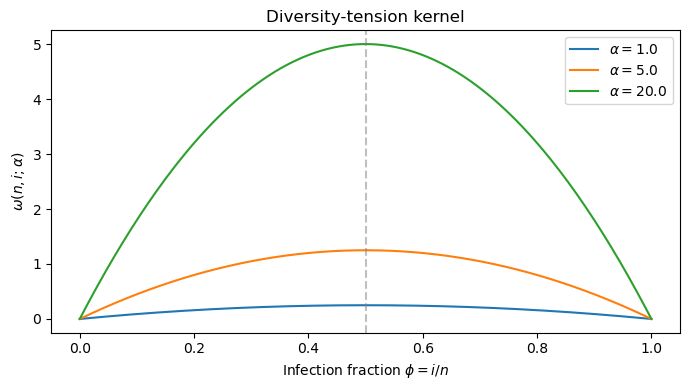

In [7]:
alpha_vals = [1.0, 5.0, 20.0]
phi = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(7, 4))
for alpha in alpha_vals:
    ax.plot(phi, alpha * phi * (1 - phi), label=f'$\\alpha={alpha}$')

ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Infection fraction $\phi = i/n$')
ax.set_ylabel('$\\omega(n, i; \\alpha)$')
ax.set_title('Diversity-tension kernel')
ax.legend()
plt.tight_layout()
plt.show()

## 5 — End-to-end summary

```
group_statistics.txt
  │
  ├─ group_size_n / group_size_p  ──►  pn[n]   ──►  pnmat[n,i]
  │                                                    │
  │                                     used in r and ρ calculations
  │                                     (weight each (n,i) cell by P(n))
  │
  └─ membership_k / membership_g  ──►  gm[k]   ──►  ρ = r · Σ k(k-1)s_k g_k / Σ k s_k g_k
                                                       │
                                          controls how fast infection spreads
                                          through overlapping group memberships
```

The network topology enters the ODE **only through** `pn` and `gm`. Everything else ($\lambda$, $\nu$, $\alpha$, $\mu$) is a dynamical parameter, not a structural one. This clean separation means the same ODE can be run on any network by swapping these two distributions — which is exactly how `vacc_sweep.py` supports `--network` generalisation.

## 6 — Comparing empirical vs. synthetic networks

The synthetic `delta_k` and `poisson_k` networks all share the **same group-size distribution** as `Thiers13`, but replace the empirical $g(k)$ with a controlled one. This lets you isolate membership heterogeneity as the only variable.

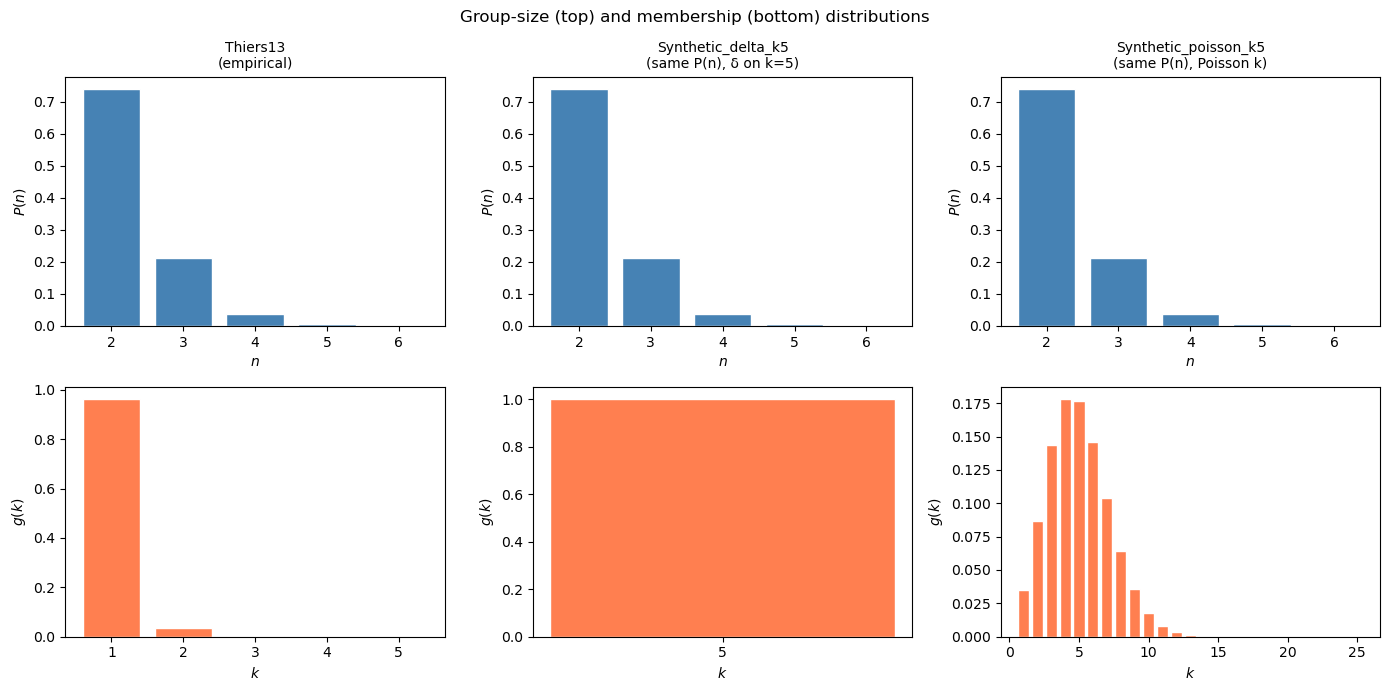

In [8]:
compare = ['Thiers13', 'Synthetic_delta_k5', 'Synthetic_poisson_k5']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col, net in enumerate(compare):
    d = data[net]

    # Group-size distribution
    ax = axes[0, col]
    ax.bar(d['group_size_n'], d['group_size_p'], color='steelblue', edgecolor='white')
    ax.set_title(net)
    ax.set_xlabel('$n$')
    ax.set_ylabel('$P(n)$')
    ax.set_xticks(d['group_size_n'])

    # Membership distribution
    ax = axes[1, col]
    ax.bar(d['membership_k'], d['membership_g'], color='coral', edgecolor='white')
    ax.set_xlabel('$k$')
    ax.set_ylabel('$g(k)$')
    if len(d['membership_k']) <= 15:
        ax.set_xticks(d['membership_k'])

axes[0, 0].set_title('Thiers13\n(empirical)', fontsize=10)
axes[0, 1].set_title('Synthetic_delta_k5\n(same P(n), δ on k=5)', fontsize=10)
axes[0, 2].set_title('Synthetic_poisson_k5\n(same P(n), Poisson k)', fontsize=10)

plt.suptitle('Group-size (top) and membership (bottom) distributions', fontsize=12)
plt.tight_layout()
plt.show()